<a href="https://colab.research.google.com/github/JeromePunnoose/Linear-Prediction-for-System-Identification/blob/main/linear_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Frame Length = 32 samples
Number of Frames = 8

Processing Frame 1/8

Processing Frame 2/8

Processing Frame 3/8

Processing Frame 4/8

Processing Frame 5/8

Processing Frame 6/8

Processing Frame 7/8

Processing Frame 8/8

Reconstruction MSE = 1.327635e-24

OPTIMAL REFLECTION COEFFICIENTS (MODEL PARAMETERS)

--- Frame 1 ---
  Stage  1: K =  0.331636
  Stage  2: K =  0.741163
  Stage  3: K =  0.064843
  Stage  4: K =  0.241633
  Stage  5: K = -0.144509
  Stage  6: K = -0.220842
  Stage  7: K =  0.060637
  Stage  8: K =  0.039638
  Stage  9: K =  0.031469
  Stage 10: K = -0.151624
  Stage 11: K = -0.019471
  Stage 12: K =  0.153667
  Stage 13: K =  0.022345
  Stage 14: K = -0.249585
  Stage 15: K =  0.084864
  Stage 16: K = -0.146198
  Stage 17: K =  0.008646
  Stage 18: K = -0.137904
  Stage 19: K = -0.104772
  Stage 20: K =  0.072625
  Stage 21: K = -0.043507
  Stage 22: K =  0.142717
  Stage 23: K =  0.021320
  Stage 24: K = -0.074023
  Stage 25: K = -0.068782
  Stage 26: K = -0.0385

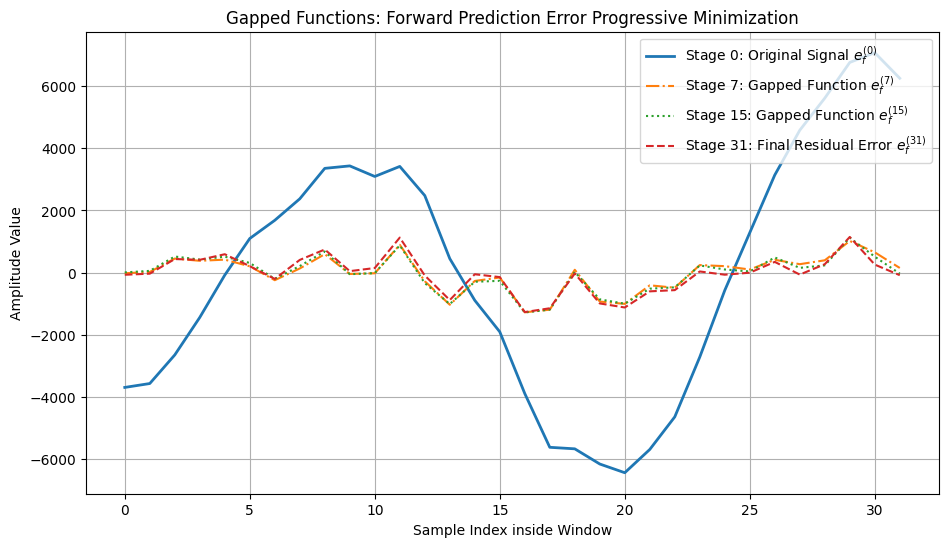

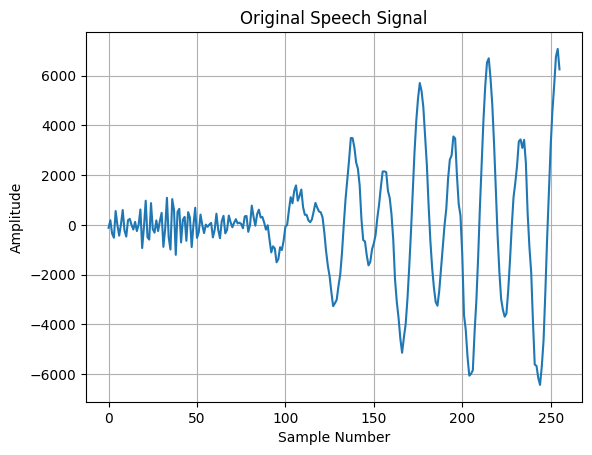

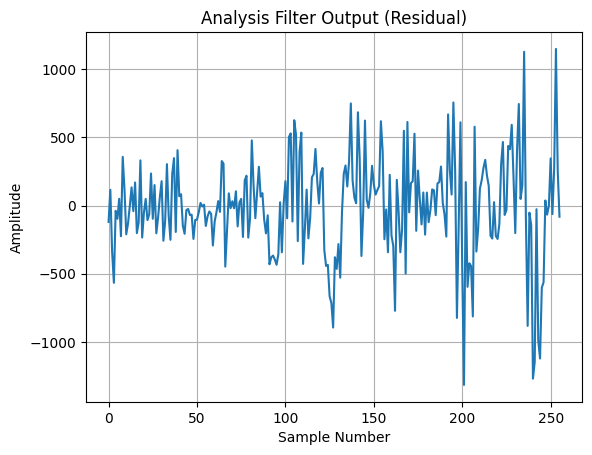

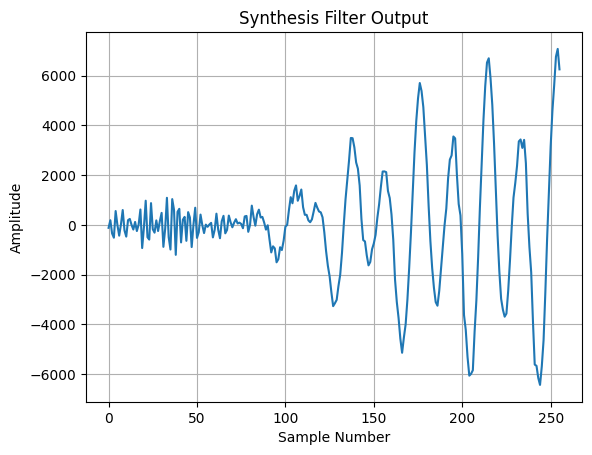

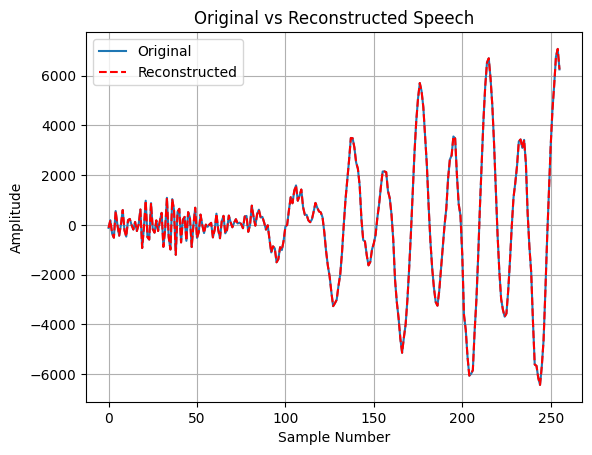

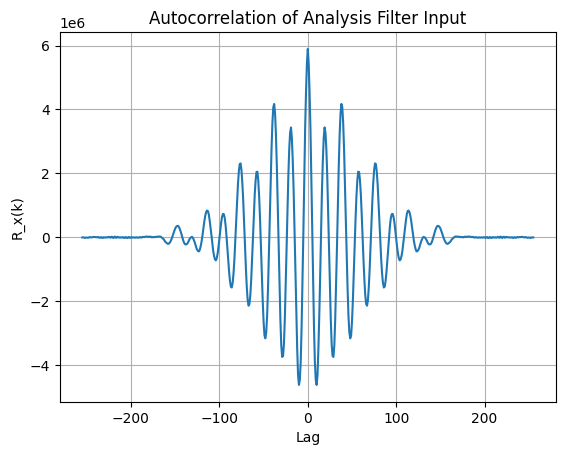

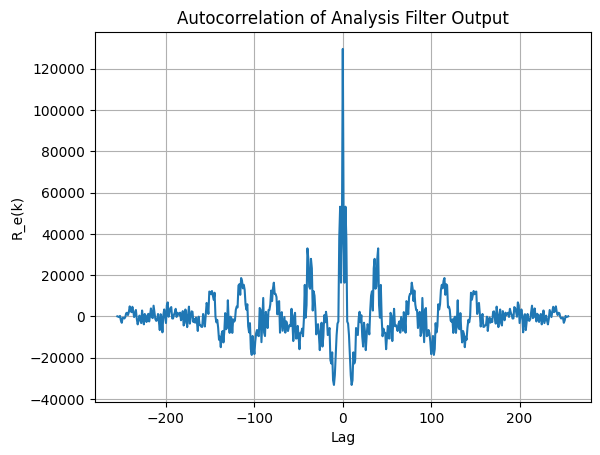

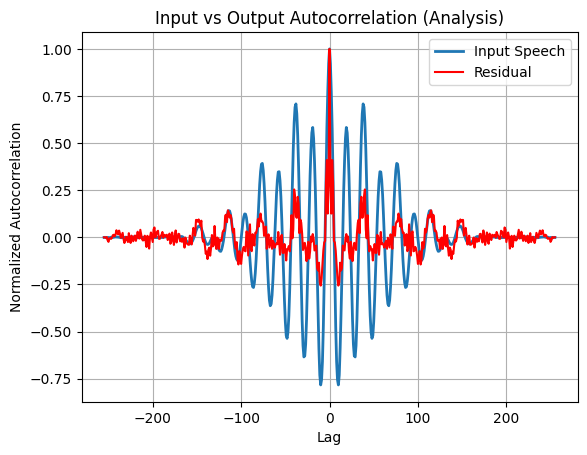

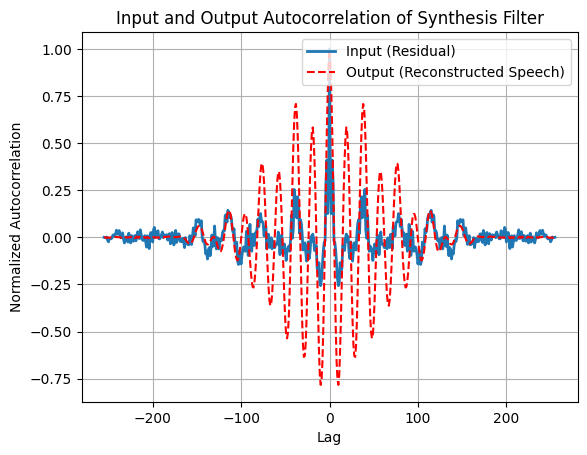

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# HELPER FUNCTIONS (MATLAB EQUIVALENTS)
# =====================================================

def matlab_xcorr_biased(signal1, signal2=None):
    """
    Replicates MATLAB's r = xcorr(x, 'biased') or xcorr(x, y, 'biased')
    Returns the autocorrelation/cross-correlation sequence and its lags.
    """
    if signal2 is None:
        signal2 = signal1

    n = len(signal1)
    # Full convolution/correlation length is 2*n - 1
    corr = np.correlate(signal1, signal2, mode='full')
    # Biased normalization divides by the length of the input vector
    corr_biased = corr / n

    lags = np.arange(-(n - 1), n)
    return corr_biased, lags


def native_levinson(r, order):
    """
    Pure NumPy implementation of the Levinson-Durbin recursion algorithm.
    Matches MATLAB's [A, E, K] = levinson(r, p) output structure.

    Returns:
    A : Predictor coefficients (polynomial format: [1.0, a1, a2, ..., ap])
    E : Final prediction error variance
    K : Reflection coefficients (gammas) array of size 'order'
    """
    A = np.array([1.0])
    E = r[0]
    K = np.zeros(order)

    for m in range(order):
        # Calculate the next cross-coupling numerator component
        num = 0.0
        for i in range(len(A)):
            num += A[i] * r[m + 1 - i]

        # Reflection coefficient equation: k_m = -num / E_prev
        gamma = -num / E
        K[m] = gamma

        # Update predictor polynomial coefficients matrix
        A_new = np.zeros(len(A) + 1)
        A_new[:len(A)] += A
        A_new[1:] += gamma * A[::-1]
        A = A_new

        # Diminish error energy across the step boundary stage
        E = E * (1.0 - gamma**2)

    return A, E, K

# =====================================================
# SPEECH DATA
# =====================================================
x = np.array([
-120,186,-348,-517,555,-5,-434,17,595,-225,-473,189,237,-3,-188,117,
-249,12,617,-932,-92,970,-497,-592,873,-175,-314,178,-249,149,481,-884,
-166,1087,-497,-991,1034,606,-1205,523,644,-706,205,320,-642,512,294,-892,
3,688,-525,-298,412,-9,-331,9,-79,11,80,-505,-200,449,-196,-538,
144,363,-341,-203,373,106,-98,86,227,54,88,37,-136,337,359,-281,
-4,772,317,-34,427,610,296,318,90,-192,-17,-583,-1108,-863,-946,-1505,
-1381,-899,-1012,-637,-73,-1,594,1112,867,1369,1585,968,1164,1420,709,403,
402,181,105,220,540,882,693,538,503,304,-296,-1051,-1640,-2066,-2706,-3267,
-3150,-3013,-2460,-2001,-1129,-5,1023,1795,2596,3491,3482,3114,2508,2256,1581,231,
-612,-666,-1222,-1628,-1490,-980,-747,-402,284,827,1530,2143,2147,2117,1361,1078,
418,-603,-2202,-3100,-3740,-4572,-5140,-4530,-3996,-3005,-1731,-308,1260,2898,4169,5079,
5698,5376,4730,3589,2403,760,-658,-1734,-2531,-3103,-3249,-2651,-1758,-870,-17,659,
1860,2621,2790,3551,3473,1997,837,380,-1169,-3620,-4224,-5309,-6060,-5987,-5841,-4288,
-3035,-1301,703,2439,4205,5564,6520,6693,5896,4825,3262,1413,-429,-1887,-2974,-3409,
-3690,-3565,-2645,-1439,-79,1097,1682,2373,3352,3431,3091,3414,2477,450,-891,-1903,
-3887,-5615,-5664,-6152,-6432,-5684,-4636,-2713,-569,1284,3138,4577,5609,6757,7069,6248
], dtype=float)

# =====================================================
# PARAMETERS
# =====================================================
Fs = 8000
frame_ms = 4

frame_len = int(np.round(Fs * frame_ms / 1000))
numFrames = len(x) // frame_len

print(f"Frame Length = {frame_len} samples")
print(f"Number of Frames = {numFrames}")

analysis_output = []
synthesis_output = []
allK = []

# Frame-to-frame continuous delay matching buffers
eb_state = np.zeros(frame_len - 1)
ebs_state = np.zeros(frame_len - 1)

# =====================================================
# FRAME PROCESSING LOOP
# =====================================================
for f in range(numFrames):
    print(f"\nProcessing Frame {f+1}/{numFrames}")

    idx1 = f * frame_len
    idx2 = (f + 1) * frame_len
    frame = x[idx1:idx2]

    # -------------------------------------------------
    # Autocorrelation & Native Levinson-Durbin
    # -------------------------------------------------
    r_full, _ = matlab_xcorr_biased(frame)
    r = r_full[frame_len - 1:]

    p = frame_len - 1  # Lattice stages

    # Run the user-defined native algorithm
    _, _, K = native_levinson(r, order=p)

    # Restrict coefficients inside safe boundaries to guarantee stability
    K = np.clip(K, -0.995, 0.995)
    allK.append(K)

    # -------------------------------------------------
    # MANUAL LATTICE ANALYSER (FIR Lattice)
    # -------------------------------------------------
    ef = np.zeros((p + 1, frame_len))
    eb = np.zeros((p + 1, frame_len))

    ef[0, :] = frame
    eb[0, :] = frame

    for n in range(frame_len):
        for stage in range(p):
            if n > 0:
                eb_delayed = eb[stage, n - 1]
            else:
                eb_delayed = eb_state[stage]

            ef[stage + 1, n] = ef[stage, n] + K[stage] * eb_delayed
            eb[stage + 1, n] = K[stage] * ef[stage, n] + eb_delayed

    eb_state = eb[:p, -1]
    residual = ef[p, :]
    analysis_output.extend(residual)

    # -------------------------------------------------
    # MANUAL LATTICE SYNTHESIZER (IIR Inverse Lattice)
    # -------------------------------------------------
    efs = np.zeros((p + 1, frame_len))
    ebs = np.zeros((p + 1, frame_len))
    reconstructed_frame = np.zeros(frame_len)

    for n in range(frame_len):
        efs[p, n] = residual[n]

        for stage in range(p - 1, -1, -1):
            if n > 0:
                ebs_delayed = ebs[stage, n - 1]
            else:
                ebs_delayed = ebs_state[stage]

            efs[stage, n] = efs[stage + 1, n] - K[stage] * ebs_delayed
            ebs[stage + 1, n] = K[stage] * efs[stage, n] + ebs_delayed

        reconstructed_frame[n] = efs[0, n]
        ebs[0, n] = efs[0, n]

    ebs_state = ebs[:p, -1]
    synthesis_output.extend(reconstructed_frame)

# Convert outputs to clean arrays
analysis_output = np.array(analysis_output)
synthesis_output = np.array(synthesis_output)

# =====================================================
# STATISTICAL ANALYSIS (Post-Loop Evaluation Block)
# =====================================================
Rin, lag_in = matlab_xcorr_biased(x)
Rout, lag_out = matlab_xcorr_biased(analysis_output)

Rin_n = Rin / np.max(np.abs(Rin))
Rout_n = Rout / np.max(np.abs(Rout))

Rsyn_in, lag_syn_in = matlab_xcorr_biased(analysis_output)
Rsyn_out, lag_syn_out = matlab_xcorr_biased(synthesis_output)

Rsyn_in_n = Rsyn_in / np.max(np.abs(Rsyn_in))
Rsyn_out_n = Rsyn_out / np.max(np.abs(Rsyn_out))

err = x[:len(synthesis_output)] - synthesis_output
print("\n" + "="*40)
print(f"Reconstruction MSE = {np.mean(err**2):.6e}")
print("="*40)

# =====================================================
# EXTRA EXTRACTION: REFLECTION COEFFICIENTS & GAPPED FUNCTIONS
# =====================================================

print("\n" + "="*50)
print("OPTIMAL REFLECTION COEFFICIENTS (MODEL PARAMETERS)")
print("="*50)

# Print reflection coefficients for each frame
for frame_idx, K_frame in enumerate(allK):
    print(f"\n--- Frame {frame_idx + 1} ---")
    for stage_idx, k_val in enumerate(K_frame):
        # Format matching MATLAB's display profile
        print(f"  Stage {stage_idx + 1:2d}: K = {k_val: .6f}")

print("\n" + "="*50)
print("PLOTTING GAPPED FUNCTIONS FOR EVALUATION")
print("="*50)

# Extract and plot the Gapped Functions (forward prediction errors)
# using the tracked 'ef' dictionary from the first processed frame window
plt.figure(figsize=(11, 6))

# Stage 0 represents the un-filtered initial signal entry
plt.plot(ef[0], label='Stage 0: Original Signal $e_f^{(0)}$', linewidth=2)

# Intermediate stages show progressive energy minimization
plt.plot(ef[int(M/4)], '-.', label=f'Stage {int(M/4)}: Gapped Function $e_f^{{({int(M/4)})}}$', linewidth=1.5)
plt.plot(ef[int(M/2)], ':', label=f'Stage {int(M/2)}: Gapped Function $e_f^{{({int(M/2)})}}$', linewidth=1.5)

# The final stage is the fully minimized residual error output
plt.plot(ef[M], '--', label=f'Stage {M}: Final Residual Error $e_f^{{({M})}}$', linewidth=1.5)

plt.title('Gapped Functions: Forward Prediction Error Progressive Minimization')
plt.xlabel('Sample Index inside Window')
plt.ylabel('Amplitude Value')
plt.legend(loc='upper right')
plt.grid(True)

# Note: plt.show() is called here to ensure the figure windows render immediately
plt.show()

# =====================================================
# VISUALIZATION PLOTS
# =====================================================

# 1. Original Speech Waveform
plt.figure()
plt.plot(x, linewidth=1.5)
plt.title('Original Speech Signal')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.grid(True)

# 2. Residual Output
plt.figure()
plt.plot(analysis_output, linewidth=1.5)
plt.title('Analysis Filter Output (Residual)')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.grid(True)

# 3. Reconstructed Speech Waveform
plt.figure()
plt.plot(synthesis_output, linewidth=1.5)
plt.title('Synthesis Filter Output')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.grid(True)

# 4. Superimposed Waveform Verification
plt.figure()
plt.plot(x, label='Original', linewidth=1.5)
plt.plot(synthesis_output, 'r--', label='Reconstructed', linewidth=1.5)
plt.title('Original vs Reconstructed Speech')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# 5. Autocorrelation Analysis Input
plt.figure()
plt.plot(lag_in, Rin, linewidth=1.5)
plt.title('Autocorrelation of Analysis Filter Input')
plt.xlabel('Lag')
plt.ylabel('R_x(k)')
plt.grid(True)

# 6. Autocorrelation Analysis Residual
plt.figure()
plt.plot(lag_out, Rout, linewidth=1.5)
plt.title('Autocorrelation of Analysis Filter Output')
plt.xlabel('Lag')
plt.ylabel('R_e(k)')
plt.grid(True)

# 7. Superimposed Analysis Spectrum Comparisons
plt.figure()
plt.plot(lag_in, Rin_n, label='Input Speech', linewidth=2)
plt.plot(lag_out, Rout_n, 'r', label='Residual', linewidth=1.5)
plt.title('Input vs Output Autocorrelation (Analysis)')
plt.xlabel('Lag')
plt.ylabel('Normalized Autocorrelation')
plt.legend()
plt.grid(True)

# 8. Superimposed Synthesis Spectral Comparisons
plt.figure()
plt.plot(lag_syn_in, Rsyn_in_n, label='Input (Residual)', linewidth=2)
plt.plot(lag_syn_out, Rsyn_out_n, 'r--', label='Output (Reconstructed Speech)', linewidth=1.5)
plt.title('Input and Output Autocorrelation of Synthesis Filter')
plt.xlabel('Lag')
plt.ylabel('Normalized Autocorrelation')
plt.legend()
plt.grid(True)

plt.show()